In [1]:
# dependencies
import pandas as pd
import scipy
import scipy.interpolate as sci_int
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sci_stats
import cartopy.crs as ccrs
import geopandas as gpd
import geodatasets
import shapely
import xarray

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap


from sklearn.preprocessing import MinMaxScaler
import hdbscan

from joblib import Parallel, delayed
from fast_histogram import histogram2d
import pyarrow

In [3]:
# load data
beach_clusters = pd.read_parquet('/home/codycruz/drifters_watersheds/watershed_stability_outputs/watershed_stability_3regime_200_main_diag_13086771/regime2_SM,EM/consensus_cluster_df.parquet')

In [4]:
from matplotlib.colors import ListedColormap
cluster_labels = sorted(beach_clusters['HDBSCAN'].dropna().unique())

paired = plt.get_cmap('tab20').colors
custom_cmap = ListedColormap(paired)

# Map cluster IDs → integer indices (needed for cmap)
cluster_to_idx = {cid: i for i, cid in enumerate(cluster_labels)}

# Colors for manual use (centroids, second plot, etc.)
colors = custom_cmap(np.linspace(0, 1, len(cluster_labels)))
cluster_colors = {cid: colors[i] for cid, i in cluster_to_idx.items()}

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

In [5]:
# set plotting text size parameters
## set plotting text size parameters
plt.rcParams.update({
    'axes.titlesize': 30,
    'axes.labelsize': 24, 
    'xtick.labelsize': 18,  
    'ytick.labelsize': 18,  
    'legend.fontsize': 12, 
    'legend.title_fontsize':12,
    'figure.titlesize': 30})

In [6]:
# Set the random seed
random_seed = 42
np.random.seed(random_seed)

In [7]:
len(beach_clusters.drop_duplicates(subset='id', keep='last'))

3195

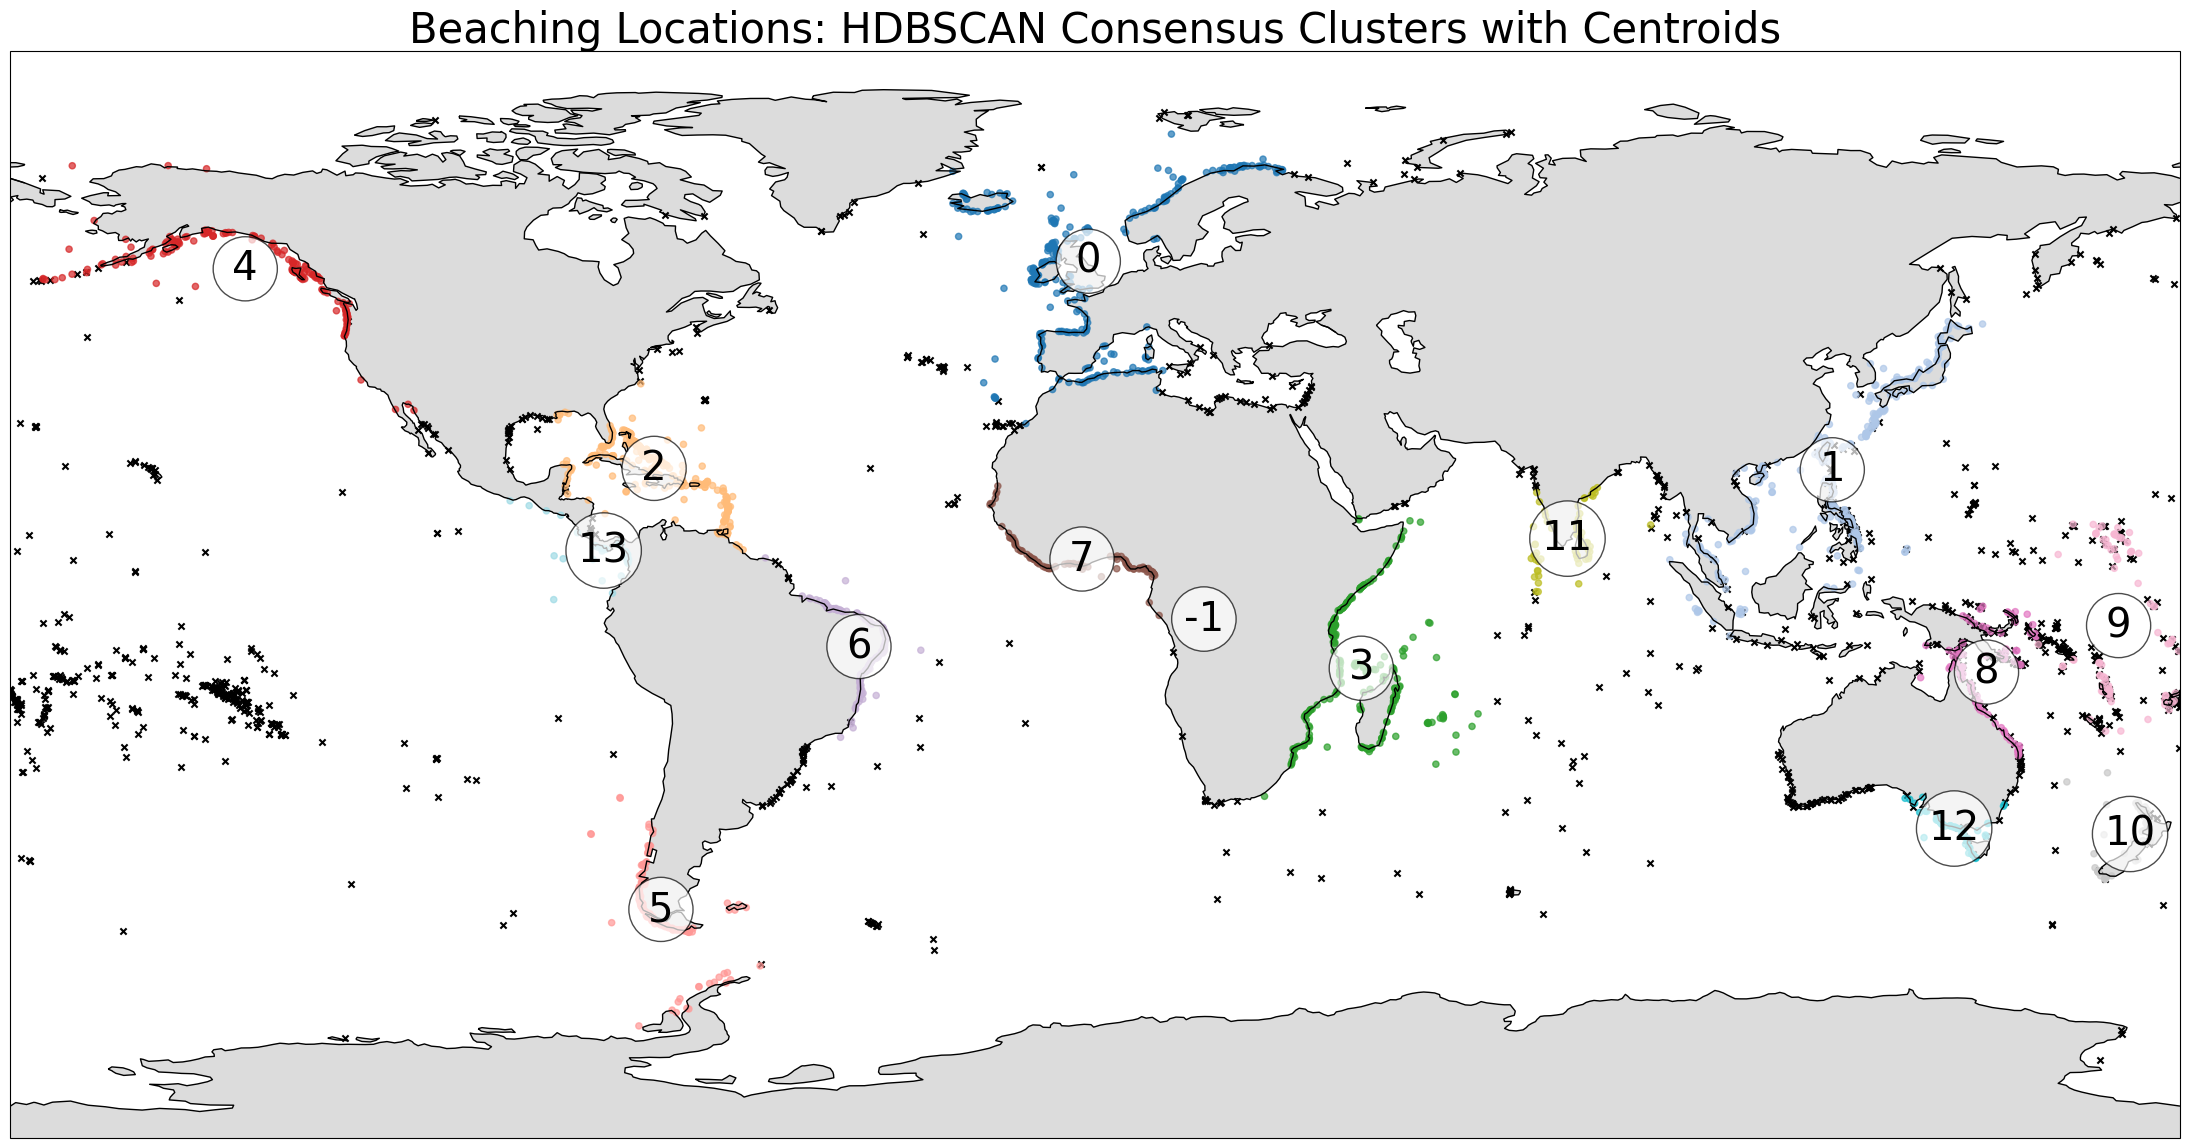

In [8]:
# Load original trajectory data and extract beaching points
beach_full = pd.read_parquet('/home/codycruz/drifters_watersheds/undrogued_beach.parquet')

# Get the last point (beaching location) for each trajectory
beaching_points = (
    beach_full
    .sort_values(['id', 'time'])
    .drop_duplicates(subset='id', keep='last')[['id', 'lat', 'lon']]
    .reset_index(drop=True)
)

# Merge with consensus clusters
beach_clusters = beach_clusters.merge(beaching_points, on='id', how='left')

# Now the plot will work:
fig = plt.figure(figsize=(22, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.coastlines()
world.plot(ax=ax, color='gainsboro', edgecolor='none')

# Noise points
noise_mask = (beach_clusters['HDBSCAN'] == -1)
ax.scatter(
    beach_clusters.loc[noise_mask, 'lon'],
    beach_clusters.loc[noise_mask, 'lat'],
    marker='x',
    color='black',
    s=20,
    label='Noise Points'
)

# Clustered points with colors
clustered_mask = (beach_clusters['HDBSCAN'] != -1)
label_indices = np.array([cluster_to_idx[l] for l in beach_clusters.loc[clustered_mask, 'HDBSCAN']])

scatter1 = ax.scatter(
    beach_clusters.loc[clustered_mask, 'lon'],
    beach_clusters.loc[clustered_mask, 'lat'],
    marker='o',
    c=label_indices,
    cmap=custom_cmap,
    alpha=0.7,
    s=20
)

# Centroids with labels
for cluster_id in cluster_labels:
    cluster_mask = (beach_clusters['HDBSCAN'] == cluster_id)
    cluster_points = beach_clusters.loc[cluster_mask, ['lat', 'lon']].values
    
    centroid = np.mean(cluster_points, axis=0)
    ax.text(centroid[1], centroid[0], str(int(cluster_id)), fontsize=29, 
            ha='center', va='center', color='black',
            bbox=dict(boxstyle='circle', facecolor='white', alpha=0.7))

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Beaching Locations: HDBSCAN Consensus Clusters with Centroids')
plt.tight_layout()
plt.show()

## Hawaii Zoom

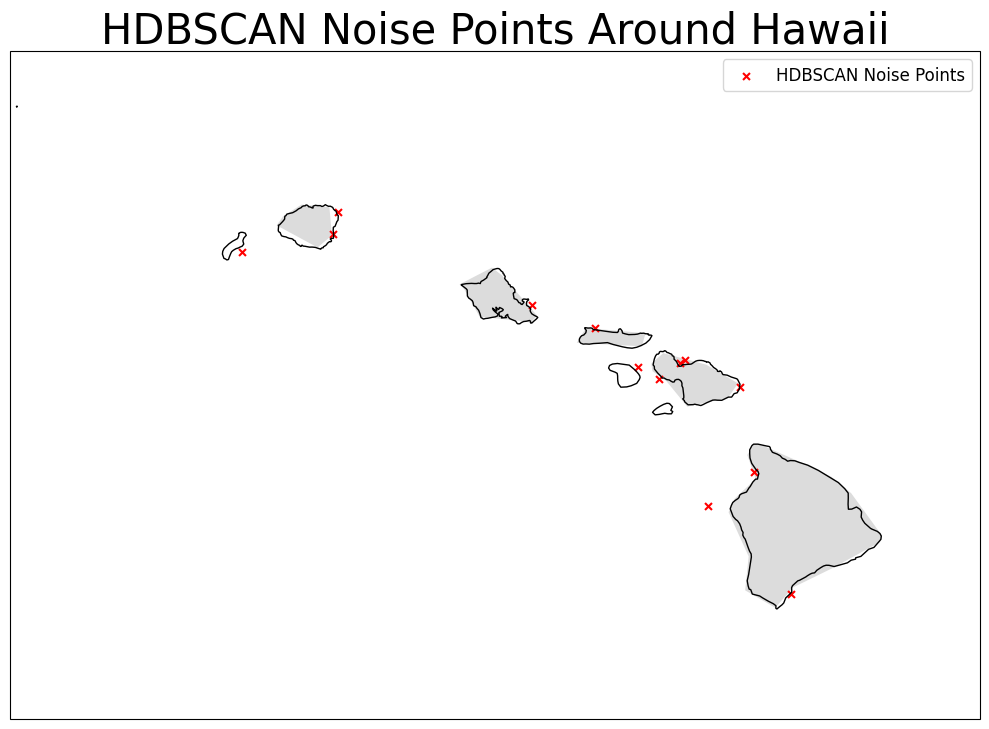

In [19]:
# Load original trajectory data and extract beaching points
beach_full = pd.read_parquet('/home/codycruz/drifters_watersheds/undrogued_beach.parquet')

beaching_points = (
    beach_full
    .sort_values(['id', 'time'])
    .drop_duplicates(subset='id', keep='last')[['id', 'lat', 'lon']]
    .reset_index(drop=True)
)

# Remove any existing lat/lon columns from prior merges
beach_clusters = beach_clusters.drop(
    columns=[c for c in beach_clusters.columns if c in ['lat', 'lon', 'lat_x', 'lon_x', 'lat_y', 'lon_y']],
    errors='ignore'
)

# Merge cleanly
beach_clusters = beach_clusters.merge(beaching_points, on='id', how='left')

# Keep only HDBSCAN noise points
noise = beach_clusters[beach_clusters['HDBSCAN'] == -1].dropna(subset=['lat', 'lon'])

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Hawaii extent: lon west/east, lat south/north
ax.set_extent([-162, -154, 18, 23.5], crs=ccrs.PlateCarree())

ax.coastlines(resolution='10m')
world.plot(ax=ax, color='gainsboro', edgecolor='none')

ax.scatter(
    noise['lon'],
    noise['lat'],
    marker='x',
    color='r',
    s=25,
    label='HDBSCAN Noise Points',
    transform=ccrs.PlateCarree()
)

ax.legend()
plt.title('HDBSCAN Noise Points Around Hawaii')
plt.tight_layout()
plt.show()

In [26]:
cluster_ids = sorted([c for c in cluster_labels if c != -1])

beach_clusters_select = beach_clusters[beach_clusters['HDBSCAN'].isin(cluster_ids)]

def get_cluster_ids(cluster_ids, dataframe):
    """Get all trajectory IDs belonging to specified clusters."""
    ids = []
    for cluster in cluster_ids:
        ids.extend(dataframe[dataframe['HDBSCAN'] == cluster]['id'].unique().tolist())
    return ids

watersheds = {
    'N_Pacific': get_cluster_ids([4], beach_clusters_select),
    'W_Pacific': get_cluster_ids([1], beach_clusters_select),
    'SW_Pacific': get_cluster_ids([8], beach_clusters_select),
    'N_Indian': get_cluster_ids([11], beach_clusters_select),
    'W_Indian': get_cluster_ids([3], beach_clusters_select),
    'Mid_Atlantic': get_cluster_ids([7], beach_clusters_select),
    'NE_Atlantic': get_cluster_ids([0], beach_clusters_select),
    'NW_Atlantic': get_cluster_ids([2], beach_clusters_select),
    'Southern_Ocean_Australia': get_cluster_ids([12], beach_clusters_select),
    'Tasman_Sea': get_cluster_ids([10], beach_clusters_select),
    'W_Central_Pacific': get_cluster_ids([9], beach_clusters_select),
    'SW_Atlantic': get_cluster_ids([6], beach_clusters_select),
    'Southern_Ocean_S_America': get_cluster_ids([5], beach_clusters_select),
    'E_Central_Pacific': get_cluster_ids([13], beach_clusters_select),
}

In [27]:
# Save watershed IDs
for watershed_name, ids in watersheds.items():
    pd.DataFrame({'id': ids}).to_csv(f'watershed_ids/{watershed_name}_ids.csv', index=False)
    print(f"{watershed_name}: {len(ids)} trajectories")

N_Pacific: 163 trajectories
W_Pacific: 301 trajectories
SW_Pacific: 88 trajectories
N_Indian: 61 trajectories
W_Indian: 240 trajectories
Mid_Atlantic: 102 trajectories
NE_Atlantic: 303 trajectories
NW_Atlantic: 265 trajectories
Southern_Ocean_Australia: 60 trajectories
Tasman_Sea: 64 trajectories
W_Central_Pacific: 84 trajectories
SW_Atlantic: 134 trajectories
Southern_Ocean_S_America: 147 trajectories
E_Central_Pacific: 42 trajectories
